In [12]:
import os 
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.time import Time, TimeDelta
import astropy.units as u
from astropy.coordinates import SkyCoord


In [13]:
work_dir  = os.getcwd()
data_dir = os.path.join(work_dir, 'data')
results_dir = os.path.join(work_dir, 'results')

if not os.path.exists(results_dir):
    os.mkdir(results_dir)

print(work_dir)
print(data_dir)

/Users/erasmopacini/LAB/analysis-of-gamma-ray-pulsars-gruppo_2
/Users/erasmopacini/LAB/analysis-of-gamma-ray-pulsars-gruppo_2/data


In [14]:
baro_name = os.path.join(data_dir, 'Goodtime_baro.fits')
baro_info = fits.open(baro_name)

baro_info.info()


Filename: /Users/erasmopacini/LAB/analysis-of-gamma-ray-pulsars-gruppo_2/data/Goodtime_baro.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      60   ()      
  1  EVENTS        1 BinTableHDU    260   27671R x 23C   [E, E, E, E, E, E, E, E, E, D, J, J, I, 3I, 32X, 32X, I, D, E, E, E, E, E]   
  2  GTI           1 BinTableHDU     76   1812R x 2C   [D, D]   


In [15]:
data_baro, header_baro = fits.getdata(baro_name, ext=1, header= True)
header_baro

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                   98 / width of table in bytes                        
NAXIS2  =                27671 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   23 / number of fields in each row                   
TTYPE1  = 'ENERGY  '           / energy of event                                
TFORM1  = 'E       '           / data format of field: 4-byte REAL              
TTYPE2  = 'RA      '           / right ascension (J2000) of event               
TFORM2  = 'E       '           / data format of field: 4-byte REAL              
TTYPE3  = 'DEC     '        

In [16]:
baro_table = Table(baro_info[1].data)

baro_table

ENERGY,RA,DEC,L,B,THETA,PHI,ZENITH_ANGLE,EARTH_AZIMUTH_ANGLE,TIME,EVENT_ID,RUN_ID,RECON_VERSION,CALIB_VERSION,EVENT_CLASS,EVENT_TYPE,CONVERSION_TYPE,LIVETIME,DIFRSP0,DIFRSP1,DIFRSP2,DIFRSP3,DIFRSP4
float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int32,int32,int16,int16[3],bool[32],bool[32],int16,float64,float32,float32,float32,float32,float32
1483.4395,302.3351,38.08736,74.95465,2.7358353,30.14574,250.96269,62.33644,7.782152,243668056.5820645,9861480,243663173,0,0 .. 0,False .. True,False .. False,1,53.24988570809364,0.0,0.0,0.0,0.0,0.0
711.07776,302.8759,38.973904,75.929726,2.8639202,30.09626,19.380842,62.540516,317.8381,243669020.5856177,11821245,243663173,0,0 .. 0,False .. True,False .. True,0,33.18728172779083,0.0,0.0,0.0,0.0,0.0
470.59518,302.57922,37.870136,74.87687,2.4562378,23.895866,346.79962,57.94011,326.18747,243691731.0013893,15497462,243686103,0,0 .. 0,False .. True,False .. True,0,82.47164613008499,0.0,0.0,0.0,0.0,0.0
488.2935,302.78595,38.73893,75.69438,2.794168,55.546215,216.14186,83.77583,42.52168,243730419.555727,8182069,243725796,0,0 .. 0,False .. True,False .. False,1,104.30561146140099,0.0,0.0,0.0,0.0,0.0
857.729,302.52985,37.673817,74.69081,2.382034,60.459282,210.365,88.4058,47.772835,243741741.07520553,7008701,243737748,0,0 .. 0,False .. True,False .. False,1,102.13682299852371,0.0,0.0,0.0,0.0,0.0
256.87405,302.56714,37.925716,74.91833,2.4945052,33.26907,45.998642,63.48047,311.06244,243749487.02815875,620126,243748990,0,0 .. 0,False .. True,False .. False,1,261.9740666747093,0.0,0.0,0.0,0.0,0.0
143.05614,302.20813,37.846306,74.69753,2.6892807,37.244503,58.69942,66.58814,308.60095,243749593.90236858,832924,243748990,0,0 .. 0,False .. True,False .. True,0,59.20995029807091,0.0,0.0,0.0,0.0,0.0
304.9893,302.45816,38.39783,75.26821,2.8232603,65.41252,108.6403,93.77527,315.03964,243761888.1628361,3029055,243760583,0,0 .. 0,False .. True,False .. False,1,66.6703405380249,0.0,0.0,0.0,0.0,0.0
429.39047,302.37845,38.18599,75.05611,2.7607355,19.550413,324.44055,54.49005,333.07532,243783365.8183449,5952467,243781394,0,0 .. 0,False .. True,False .. True,0,67.9160684645176,0.0,0.0,0.0,0.0,0.0


In [17]:
times = baro_table['TIME']
max_times = times.max()
min_times = times.min()
bin_size = 10  
bins = np.arange(times.min(), times.max(), bin_size)

counts, edges = np.histogram(times, bins=bins)

print(f"tempo massimo:{max_times}, tempo minimo {min_times}")

tempo massimo:251423809.5966678, tempo minimo 243649807.42793787


Punto più significativo:
f0 = 9.63934492 Hz
fdot = -8.884e-12 Hz/s
Z4^2 = 1133.011


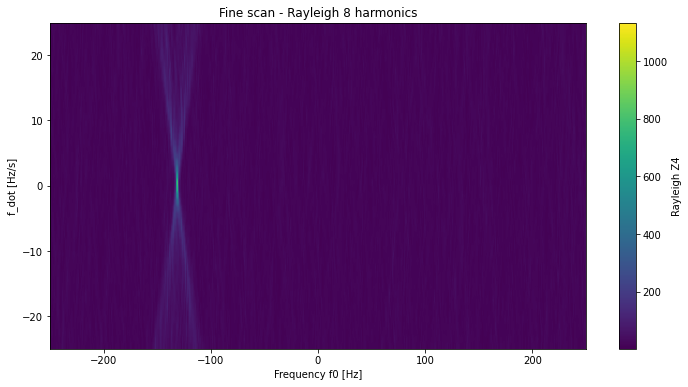

In [18]:
# First scan

times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63935
fdot_exp = -8.8892 * 10**(-12)

df0_f = 0.3/T
dfdot_f = 0.6/T**2

f_grid_f = np.linspace(f0_exp-250*df0_f, f0_exp+250*df0_f, 500)       # frequenze Hz
fdot_grid_f = np.linspace(fdot_exp-dfdot_f*25, fdot_exp+dfdot_f*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid_f = np.zeros((len(fdot_grid_f), len(f_grid_f)))


for i, fdot in enumerate(fdot_grid_f):
    for j, f0 in enumerate(f_grid_f):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid_f[i,j] = rayleigh_Zn(phases, n_harm=8)




max_idx = np.unravel_index(np.argmax(Z_grid_f), Z_grid_f.shape)
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0_f:.8f} Hz")
print(f"fdot = {best_fdot_f:.3e} Hz/s")
print(f"Z4^2 = {best_Zn_f:.3f}")



plt.figure(figsize=(12,6))
plt.imshow(Z_grid_f, origin='lower',
           extent=[-250, 250, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Fine scan - Rayleigh 8 harmonics')
plt.show()

In [ ]:
#FINE TUNING

times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63934492
fdot_exp = -8.884 * 10**(-12)

df0_f = 0.03/T
dfdot_f = 0.06/T**2

f_grid_f = np.linspace(f0_exp-1000*df0_f, f0_exp+1000*df0_f, 2000)       # frequenze Hz
fdot_grid_f = np.linspace(fdot_exp-dfdot_f*25, fdot_exp+dfdot_f*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid_f = np.zeros((len(fdot_grid_f), len(f_grid_f)))


for i, fdot in enumerate(fdot_grid_f):
    for j, f0 in enumerate(f_grid_f):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid_f[i,j] = rayleigh_Zn(phases, n_harm=8)




max_idx = np.unravel_index(np.argmax(Z_grid_f), Z_grid_f.shape)
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0_f:.8f} Hz")
print(f"fdot = {best_fdot_f:.3e} Hz/s")
print(f"Z4^2 = {best_Zn_f:.3f}")



plt.figure(figsize=(12,6))
plt.imshow(Z_grid_f, origin='lower',
           extent=[-1000, 1000, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Fine scan - Rayleigh 8 harmonics')
plt.show()

In [ ]:
#FINE TUNING pt2

times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63934492
fdot_exp = -8.88649 * 10**(-12)

df0_f = 0.03/T
dfdot_f = 0.06/T**2

f_grid_f = np.linspace(f0_exp-500*df0_f, f0_exp+500*df0_f, 1000)       # frequenze Hz
fdot_grid_f = np.linspace(fdot_exp-dfdot_f*25, fdot_exp+dfdot_f*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid_f = np.zeros((len(fdot_grid_f), len(f_grid_f)))


for i, fdot in enumerate(fdot_grid_f):
    for j, f0 in enumerate(f_grid_f):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid_f[i,j] = rayleigh_Zn(phases, n_harm=8)




max_idx = np.unravel_index(np.argmax(Z_grid_f), Z_grid_f.shape)
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0_f:.8f} Hz")
print(f"fdot = {best_fdot_f:.5e} Hz/s")
print(f"Z4^2 = {best_Zn_f:.3f}")



plt.figure(figsize=(12,6))
plt.imshow(Z_grid_f, origin='lower',
           extent=[-500, 500, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Fine scan - Rayleigh 8 harmonics')
plt.show()

In [ ]:
phases_best_f = ( best_f0_f*(times - t0) + 0.5*best_fdot_f*(times - t0)**2 ) % 1
plt.figure(figsize=(8,6))
plt.scatter(phases_best_f, times, s=5, alpha=0.4, color = 'lightskyblue')

plt.xlabel('Fase rotazionale')
plt.ylabel('Tempi di arrivo')
plt.title('Fase rotazionale vs tempi di arrivo')

plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
plt.hist(phases_best_f, bins='auto', density = True, histtype='stepfilled')
plt.xlabel("Pulse Phase [rad]")
plt.ylabel("Weighted counts")
plt.xlim(0,1)
plt.grid()


In [ ]:

LE_mask = (baro_table['ENERGY'] > 100) & (baro_table['ENERGY'] < 1000)
HE_mask = baro_table['ENERGY'] > 1000

LE = baro_table[LE_mask]
HE = baro_table[HE_mask]

times_HE = HE['TIME']
times_LE = LE['TIME']

phases_HE = ( best_f0_f*(times_HE - t0) + 0.5*best_fdot_f*(times_HE - t0)**2 ) % 1
phases_LE = ( best_f0_f*(times_LE - t0) + 0.5*best_fdot_f*(times_LE - t0)**2 ) % 1


N_BINS = 48 # prova anche 32 o 64

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for ax, phases, label, color in zip(
    [ax1, ax2],
    [phases_LE, phases_HE],
    ['100 MeV < E < 1 GeV', 'E > 1 GeV'],
    ['steelblue', 'tomato']
):
    ax.hist(phases, bins=N_BINS, range=(0, 1),
            color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.set_ylabel("Weighted counts", fontsize=11)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.text(0.02, 0.97, label,
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))
ax1.set_ylim(0, 1000)
ax2.set_ylim(0,300)
ax2.set_xlabel('Pulse phase', fontsize=12)
plt.tight_layout()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def double_gaussian_model(phi, B, A1, mu1, sigma1, A2, mu2, sigma2):
    g1 = A1 * np.exp(-0.5 * ((phi - mu1)/sigma1)**2)
    g2 = A2 * np.exp(-0.5 * ((phi - mu2)/sigma2)**2)
    return B + g1 + g2

In [ ]:
def fit_profile(phases, bins=48):
    counts, edges = np.histogram(phases, bins=bins, range=(0,1))
    centers = 0.5 * (edges[:-1] + edges[1:])
    
    # stima iniziale (molto importante)
    B0 = np.percentile(counts, 20)
    
    # trova due massimi grezzi
    idx_sorted = np.argsort(counts)[::-1]
    mu1_0 = centers[idx_sorted[0]]
    mu2_0 = centers[idx_sorted[1]]
    
    A1_0 = counts[idx_sorted[0]] - B0
    A2_0 = counts[idx_sorted[1]] - B0
    
    sigma0 = 0.05
    
    p0 = [B0, A1_0, mu1_0, sigma0, A2_0, mu2_0, sigma0]
    
    popt, pcov = curve_fit(double_gaussian_model, centers, counts, p0=p0)
    
    return centers, counts, popt, pcov

In [ ]:
def extract_parameters(popt):
    B, A1, mu1, sigma1, A2, mu2, sigma2 = popt
    
    # ordina per fase (NON per ampiezza!)
    if mu1 > mu2:
        A1, A2 = A2, A1
        mu1, mu2 = mu2, mu1
    
    # phase lag
    phase_lag = np.abs(mu2 - mu1)
    if phase_lag > 0.5:
        phase_lag = 1 - phase_lag
    
    # amplitude ratio
    amplitude_ratio = A2 / A1
    
    return phase_lag, amplitude_ratio, B

In [ ]:
def bootstrap_errors(phases, n_boot=1000):
    lags = []
    ratios = []
    
    for _ in range(n_boot):
        sample = np.random.choice(phases, size=len(phases), replace=True)
        _, _, popt, _ = fit_profile(sample)
        lag, ratio, _ = extract_parameters(popt)
        
        lags.append(lag)
        ratios.append(ratio)
    
    return np.std(lags), np.std(ratios)

In [ ]:
centers, counts, popt, pcov = fit_profile(phases_best_f)

phase_lag, amplitude_ratio, B = extract_parameters(popt)

lag_err, ratio_err = bootstrap_errors(phases_best_f)

print(f"Phase lag = {phase_lag:.3f} ± {lag_err:.3f}")
print(f"Amplitude ratio = {amplitude_ratio:.3f} ± {ratio_err:.3f}")
print(f"Background = {B:.3f}")

In [ ]:
import matplotlib.pyplot as plt



# =========================
# RESIDUI
# =========================
model_centers = double_gaussian_model(centers, *popt)

# errore poissoniano
errors = np.sqrt(counts)
errors[errors == 0] = 1  # evita divisioni per zero

residuals = (counts - model_centers) / errors

# =========================
# FIGURA CON DUE PANNELLI
# =========================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10,8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# =========================
# PANNELLO SUPERIORE (DATI + FIT)
# =========================
bin_width = 1 / len(centers)
ax1.bar(centers, counts, width=bin_width,
        color='steelblue', alpha=0.6, edgecolor='white', label='Data')

ax1.plot(phi_fine, model, color='black', lw=2, label='Fit')


# gaussiane
ax1.plot(phi_fine, g1 + B, '--', color='red', label='Peak 1')
ax1.plot(phi_fine, g2 + B, '--', color='green', label='Peak 2')

# background
ax1.axhline(B, color='gray', linestyle='--')

# picchi
ax1.axvline(mu1, color='red', linestyle=':', alpha=0.7)
ax1.axvline(mu2, color='green', linestyle=':', alpha=0.7)

ax1.set_ylabel("Counts")
ax1.set_xlim(0,1)
ax1.legend()
ax1.grid(alpha=0.3)

ax1.set_title(f"Phase lag = {phase_lag:.3f} ± {lag_err:.3f}   |   "
              f"A2/A1 = {amplitude_ratio:.3f} ± {ratio_err:.3f}")

# =========================
# PANNELLO INFERIORE (RESIDUI)
# =========================
ax2.axhline(0, color='black', lw=1)
ax2.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(-1, color='gray', linestyle='--', alpha=0.5)

ax2.errorbar(centers, residuals, yerr=1,
             fmt='o', color='black', markersize=4)

ax2.set_xlabel("Pulse Phase")
ax2.set_ylabel("Res.")

ax2.set_ylim(-5,5)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

F = best_f0_f
FDOT = best_fdot_f

P = 1/F

PDOT = -1/(F**2) * FDOT



B = 3.2*10**(19) * np.sqrt(P*PDOT)
print(f"B = {B:.4f} G [Gauss]")

In [ ]:
tau = P/(2*PDOT)

print(f"Characteristic age of {tau} s")
print(f"Characteriscic age: {tau/(np.pi*10**7)} yrs")

In [ ]:
I = 10**45 #g cm^2

O = 2*np.pi /(P)
ODOT = -2*np.pi*PDOT/P**2

dE = I*O*ODOT
print(f"Energy loss due to rotation: dE/dt = {dE:.2e} erg/s")